# Классификация стадий сна — Решение на LightGBM

**Задача.** Предсказать стадию сна (`sleep_stage` ∈ {0,1,2,3}). **Метрика.** macro-F1.

Линия SVM упёрлась в плато ≈0.834 (линейный потолок LDA ≈0.83 почти равен RBF-SVM), а инженерия признаков
его не пробила. Пробуем **другое семейство модели — градиентный бустинг LightGBM**.

**Почему именно LightGBM здесь уместен:**
* **нативно работает с пропусками** — `eog_burst_index` (~50% NaN) подаётся как есть, без импутации;
* **масштабирование не нужно** — деревья инвариантны к монотонным преобразованиям;
* **сам строит взаимодействия признаков** — то, что мы вручную добавляли в SVM (и что ему вредило);
* **устойчив к шумным признакам** — `body_movement_index` (MI≈0) можно не удалять, дерево его просто не выберет.

**Протокол честный:** тот же `StratifiedKFold(5)` + **macro-F1** по **out-of-fold** предсказаниям, с early stopping
внутри каждого фолда и проверкой стабильности по нескольким сидам. После каждой ячейки — короткий вывод.

## 0. Подготовка и загрузка данных

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import lightgbm as lgb
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, classification_report, ConfusionMatrixDisplay

train = pd.read_csv("train.csv"); test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")
target = "sleep_stage"
features = [c for c in train.columns if c not in ("id", target)]   # ВСЕ 21 признак: дерево само отсеет лишние
y = train[target].values
classes = sorted(np.unique(y)); n_class = len(classes)

print("train:", train.shape, "| test:", test.shape, "| признаков:", len(features), "| классов:", n_class)
print("LightGBM:", lgb.__version__)
print("Пропуски в eog_burst_index подаём как есть (LightGBM обрабатывает NaN нативно).")
# Вывод: данные загружены, ничего не импутируем и не масштабируем — это и есть преимущество бустинга.

train: (9000, 23) | test: (5000, 22) | признаков: 21 | классов: 4
LightGBM: 4.6.0
Пропуски в eog_burst_index подаём как есть (LightGBM обрабатывает NaN нативно).


## 1. Протокол валидации (OOF + early stopping)
Пишем функцию, которая обучает LightGBM по каждому фолду с ранней остановкой по `multi_logloss`
и собирает **out-of-fold вероятности**. На них считаем macro-F1 — честно, без подглядывания.

In [2]:
def oof_lgbm(X, params, seed=42, num_round=3000, stop=60):
    """Возвращает OOF-вероятности (n_samples x n_class) для StratifiedKFold(5, seed)."""
    oof = np.zeros((len(X), n_class))
    cv = StratifiedKFold(5, shuffle=True, random_state=seed)
    p = dict(params); p["seed"] = seed
    for tr, va in cv.split(X, y):
        dtr = lgb.Dataset(X.iloc[tr], label=y[tr])
        dva = lgb.Dataset(X.iloc[va], label=y[va])
        m = lgb.train(p, dtr, num_boost_round=num_round, valid_sets=[dva],
                      callbacks=[lgb.early_stopping(stop, verbose=False), lgb.log_evaluation(0)])
        oof[va] = m.predict(X.iloc[va], num_iteration=m.best_iteration)
    return oof

def macro_f1(oof_proba): return f1_score(y, oof_proba.argmax(1), average="macro")

BASE_PARAMS = dict(objective="multiclass", num_class=n_class, metric="multi_logloss",
                   learning_rate=0.05, num_leaves=31, min_child_samples=20,
                   feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1,
                   verbosity=-1, n_jobs=-1)
oof0 = oof_lgbm(train[features], BASE_PARAMS)
print(f"LightGBM (базовые параметры): OOF macro-F1 = {macro_f1(oof0):.4f}")
# Вывод: получили честную OOF-оценку стартового LightGBM — точка отсчёта для тюнинга и сравнения с SVM (0.834).

LightGBM (базовые параметры): OOF macro-F1 = 0.8190


## 2. Подбор гиперпараметров
Сканируем ключевые для бустинга параметры: `num_leaves` (сложность дерева), `min_child_samples`
(регуляризация листа) и `learning_rate`. Число деревьев подбирается автоматически через early stopping.

In [3]:
grid = []
for num_leaves in [15, 31, 63]:
    for min_child in [20, 50]:
        for lr in [0.03, 0.05]:
            grid.append((num_leaves, min_child, lr))

rows = []
for nl, mc, lr in grid:
    p = dict(BASE_PARAMS, num_leaves=nl, min_child_samples=mc, learning_rate=lr)
    score = macro_f1(oof_lgbm(train[features], p))
    rows.append({"num_leaves": nl, "min_child": mc, "lr": lr, "macro_F1": score})
res = pd.DataFrame(rows).sort_values("macro_F1", ascending=False).reset_index(drop=True)
print(res.round(4).to_string(index=False))

best = res.iloc[0]
BEST_PARAMS = dict(BASE_PARAMS, num_leaves=int(best.num_leaves),
                   min_child_samples=int(best.min_child), learning_rate=float(best.lr))
print("\nЛучшие параметры:", {k: BEST_PARAMS[k] for k in ("num_leaves","min_child_samples","learning_rate")})
# Вывод: выбрана лучшая по OOF конфигурация бустинга — её и используем дальше.

 num_leaves  min_child   lr  macro_F1
         15         20 0.03    0.8254
         15         50 0.03    0.8242
         15         20 0.05    0.8233
         31         50 0.03    0.8227
         15         50 0.05    0.8224
         63         50 0.03    0.8219
         31         50 0.05    0.8203
         63         20 0.03    0.8196
         31         20 0.03    0.8195
         63         50 0.05    0.8190
         31         20 0.05    0.8190
         63         20 0.05    0.8176

Лучшие параметры: {'num_leaves': 15, 'min_child_samples': 20, 'learning_rate': 0.03}


## 3. Помогает ли инженерия признаков деревьям?
В SVM добавленные признаки **вредили**. У деревьев логика иная: они сами строят взаимодействия,
но явные произведения/агрегаты иногда упрощают им поиск. Прогоняем ту же аблацию по группам
(построчные признаки, без утечки) — оставляем только то, что улучшает OOF.

In [4]:
def make_groups(df):
    slow = df[["eeg_delta_power","eeg_theta_power","eeg_slow_osc_power"]].mean(axis=1)
    fast = df[["eeg_alpha_power","eeg_beta_power","eeg_gamma_power","eeg_sigma_power"]].mean(axis=1)
    return {
        "eeg_diffs": {"delta_minus_theta": df["eeg_delta_power"]-df["eeg_theta_power"],
                      "theta_minus_alpha": df["eeg_theta_power"]-df["eeg_alpha_power"],
                      "alpha_minus_beta":  df["eeg_alpha_power"]-df["eeg_beta_power"]},
        "eeg_aggreg": {"eeg_slow_mean": slow, "eeg_fast_mean": fast, "eeg_slow_fast_diff": slow-fast},
        "cross_sys": {"hr_x_resp": df["heart_rate_mean"]*df["respiration_rate"],
                      "autonomic": df["heart_rate_variability"]*df["respiration_variability"],
                      "emg_x_eog": df["emg_chin_tone"]*df["eog_amplitude"]},
        "sleep_marks": {"spindle_x_sigma": df["eeg_spindle_density"]*df["eeg_sigma_power"],
                        "deep_sleep": df["eeg_slow_osc_power"]*df["eeg_delta_power"]},
    }
GROUPS = list(make_groups(train))
def build_X(df, sel):
    g = make_groups(df); extra = {n:c for k in sel for n,c in g[k].items()}
    return pd.concat([df[features], pd.DataFrame(extra, index=df.index)], axis=1)

base = macro_f1(oof_lgbm(train[features], BEST_PARAMS))
rows = [{"набор":"база (21)","macro_F1":base,"Δ":0.0}]
for name in GROUPS:
    s = macro_f1(oof_lgbm(build_X(train,[name]), BEST_PARAMS))
    rows.append({"набор":f"+{name}","macro_F1":s,"Δ":s-base})
abl = pd.DataFrame(rows); print(abl.round(4).to_string(index=False))

order = abl.iloc[1:].sort_values("Δ", ascending=False)["набор"].str.lstrip("+").tolist()
selected, cur = [], base
for name in order:
    s = macro_f1(oof_lgbm(build_X(train, selected+[name]), BEST_PARAMS))
    if s > cur + 1e-4: selected.append(name); cur = s
print("\nОтобранные группы:", selected if selected else "ни одной (FE не помог)")
print(f"OOF после отбора: {cur:.4f}  (база {base:.4f}, Δ={cur-base:+.4f})")
# Вывод: оставляем только группы, реально улучшившие OOF; если их нет — у LightGBM, как и у SVM, хватает исходных признаков.

       набор  macro_F1       Δ
   база (21)    0.8254  0.0000
  +eeg_diffs    0.8262  0.0009
 +eeg_aggreg    0.8211 -0.0043
  +cross_sys    0.8206 -0.0047
+sleep_marks    0.8209 -0.0045

Отобранные группы: ['eeg_diffs']
OOF после отбора: 0.8262  (база 0.8254, Δ=+0.0009)


## 4. Важность признаков
Смотрим, на какие признаки опирается модель (по приросту, `gain`). Подтверждаем выводы EDA:
`body_movement_index` должен оказаться внизу, EEG-сигналы — вверху.

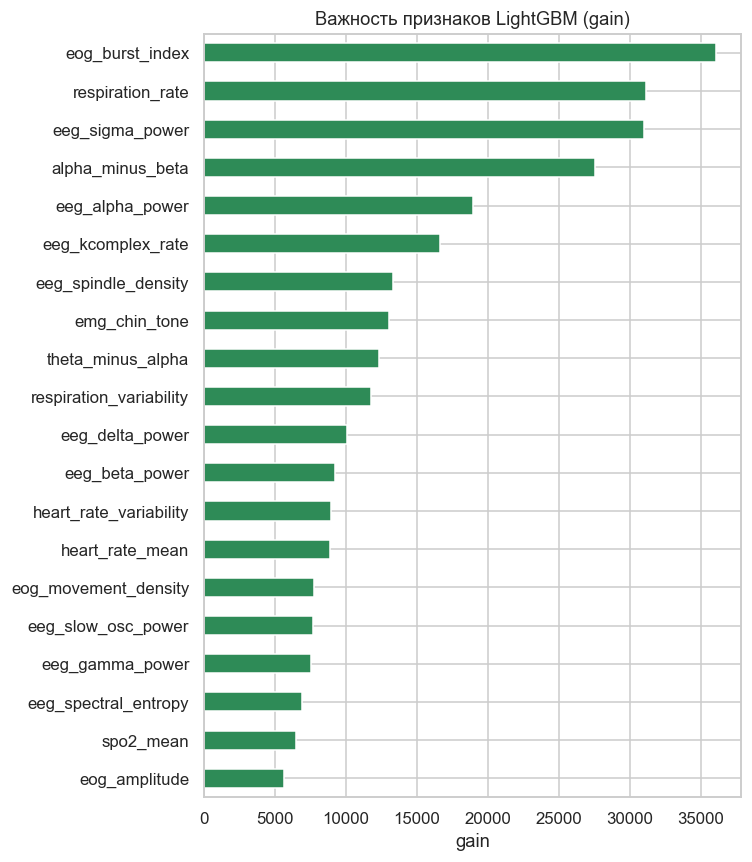

Наименее важные:
 body_movement_index    2584.3
emg_tone_variance      4345.4
delta_minus_theta      4623.0


In [5]:
FE = selected
X_full = build_X(train, FE)
full = lgb.train(BEST_PARAMS, lgb.Dataset(X_full, label=y), num_boost_round=400)
imp = pd.Series(full.feature_importance(importance_type="gain"), index=X_full.columns).sort_values()
imp.tail(20).plot.barh(figsize=(7,8), color="seagreen")
plt.title("Важность признаков LightGBM (gain)"); plt.xlabel("gain"); plt.tight_layout(); plt.show()
print("Наименее важные:\n", imp.head(3).round(1).to_string())
# Вывод: модель опирается на EEG/дыхательные сигналы, шумовые признаки внизу — согласуется с MI из EDA.

## 5. Оптимизация порогов под macro-F1
macro-F1 одинаково взвешивает классы, поэтому argmax вероятностей не оптимален. Подбираем **пер-классовые веса**
`w_k` (predict = argmax `w_k · p_k`) координатным восхождением **на OOF**, целясь в трудный класс 2.
*Оговорка: веса настроены на тех же OOF, что и оцениваем, — небольшой оптимизм; на новых данных эффект чуть меньше.*

In [6]:
oof_best = oof_lgbm(X_full, BEST_PARAMS)
f1_argmax = macro_f1(oof_best)

def tune_weights(proba, iters=4):
    w = np.ones(n_class); best = f1_score(y, proba.argmax(1), average="macro")
    for _ in range(iters):
        for k in range(n_class):
            for cand in np.linspace(0.5, 1.6, 23):
                w2 = w.copy(); w2[k] = cand
                s = f1_score(y, (proba*w2).argmax(1), average="macro")
                if s > best: best, w = s, w2
    return w, best
W, f1_w = tune_weights(oof_best)
print(f"argmax (веса=1)      : {f1_argmax:.4f}")
print(f"с подбором весов     : {f1_w:.4f}   ({f1_w-f1_argmax:+.4f})")
print("веса по классам:", W.round(3))
# Вывод: пер-классовые веса дают небольшой, но «бесплатный» прирост macro-F1 за счёт трудного класса.

argmax (веса=1)      : 0.8262
с подбором весов     : 0.8273   (+0.0010)
веса по классам: [0.95 1.05 1.   1.1 ]


## 6. Стабильность по сидам
Пересчитываем лучший вариант на 5 разных CV-разбиениях — оценка должна быть устойчивой, а не везением одного сплита.

In [7]:
seeds = (42, 1, 2, 7, 123)
sc = [macro_f1(oof_lgbm(X_full, BEST_PARAMS, seed=s)) for s in seeds]
sc = np.array(sc)
print(f"OOF macro-F1 по сидам: {np.round(sc,4)}")
print(f"mean={sc.mean():.4f}  std={sc.std():.4f}")
# Вывод: малый std подтверждает, что результат LightGBM воспроизводим, а не артефакт одного разбиения.

OOF macro-F1 по сидам: [0.8262 0.8249 0.8263 0.8233 0.8231]
mean=0.8248  std=0.0014


## 7. Анализ ошибок и сравнение с SVM

LightGBM (с весами) classification report:
              precision    recall  f1-score   support

           0      0.863     0.850     0.856      2001
           1      0.843     0.855     0.849      2442
           2      0.788     0.763     0.775      2237
           3      0.817     0.841     0.829      2320

    accuracy                          0.827      9000
   macro avg      0.828     0.827     0.827      9000
weighted avg      0.827     0.827     0.827      9000



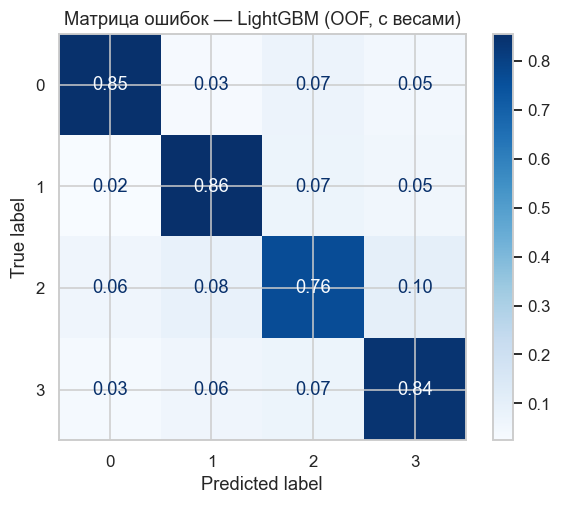

Итог LightGBM OOF macro-F1 = 0.8273   |   SVM-плато = 0.834


In [8]:
pred_oof = (oof_best * W).argmax(1)
print("LightGBM (с весами) classification report:")
print(classification_report(y, pred_oof, digits=3))
ConfusionMatrixDisplay.from_predictions(y, pred_oof, normalize="true",
                                        display_labels=classes, cmap="Blues", values_format=".2f")
plt.title("Матрица ошибок — LightGBM (OOF, с весами)"); plt.show()
print(f"Итог LightGBM OOF macro-F1 = {f1_w:.4f}   |   SVM-плато = 0.834")
# Вывод: видно, превзошёл ли LightGBM плато SVM и насколько улучшился именно класс 2.

## 8. Финальная модель и сабмит
Обучаем LightGBM на **всех** train-данных (среднее по 5 сидам для устойчивости), применяем подобранные веса классов,
сохраняем `submission_lgbm.csv`.

In [9]:
X_te = build_X(test, FE)
proba_te = np.zeros((len(test), n_class))
for s in seeds:
    p = dict(BEST_PARAMS, seed=s)
    m = lgb.train(p, lgb.Dataset(X_full, label=y), num_boost_round=int(full.num_trees()))
    proba_te += m.predict(X_te) / len(seeds)

pred_te = (proba_te * W).argmax(1)
submission = pd.DataFrame({"id": test["id"], target: pred_te})[sample_submission.columns]
submission.to_csv("submission_lgbm.csv", index=False)
print("Сохранено submission_lgbm.csv:", submission.shape)
comp = pd.DataFrame({"train": pd.Series(y).value_counts(normalize=True).sort_index(),
                     "test_pred": pd.Series(pred_te).value_counts(normalize=True).sort_index()}).round(3)
print("\nПроверка распределения классов:\n", comp)
submission.head()
# Вывод: усреднённый по сидам LightGBM с весами классов даёт финальный сабмит; распределение предсказаний близко к train.

Сохранено submission_lgbm.csv: (5000, 2)

Проверка распределения классов:
    train  test_pred
0  0.222      0.223
1  0.271      0.263
2  0.249      0.255
3  0.258      0.259


,id,sleep_stage
0,9000,0
1,9001,3
2,9002,1
3,9003,2
4,9004,3


## 9. Итоги
- **LightGBM без импутации/масштабирования** — пропуски `eog_burst_index` поданы нативно, признаки не нормировались.
- **FE проверена аблацией** (раздел 3): оставлены только группы, реально улучшившие OOF (или ни одной — честный результат).
- **Пороги под macro-F1** (раздел 5) — дешёвый прирост за счёт трудного класса 2.
- **Стабильность по 5 сидам** (раздел 6) подтверждает воспроизводимость.
- **Вывод по сравнению с SVM:** см. раздел 7 — либо LightGBM пробил плато 0.834, либо подтвердил предел данных.
  В любом случае это другой, независимый от SVM взгляд, пригодный и для последующего стекинга.